# Detecting Anomalous & Potentially Fraudulent Reviews in the Yelp Open Dataset
### Module 24 — Final Modeling, Model Comparison & Findings

**Research question:** *Can machine-learning techniques identify potentially fraudulent or
anomalous reviews in the Yelp Open Dataset using behavioral, temporal, and linguistic patterns?*

Online reviews drive real consumer and business decisions, yet the Yelp Open Dataset has
**no ground-truth labels for fake reviews**. We therefore frame the problem as **unsupervised
anomaly detection**: engineer behavioral, temporal, and linguistic features per user, and let
several models surface reviewers whose activity deviates sharply from normal patterns. The output
is a **ranked list of suspicious users** — leads for human investigation, *not proof of fraud*.

---

#### Where this notebook fits

This is the **second of two notebooks**:

| Notebook | Scope |
|---|---|
| `capstone_eda.ipynb` (Module 21) | Memory-aware loading of the raw 5 GB JSON, data cleaning, **feature engineering** (18 behavioral / temporal / linguistic features), EDA, and a single **Isolation Forest baseline**. |
| `yelp_dataset_final_modeling.ipynb` (**this notebook**, Module 24) | Final modeling on the engineered feature matrix. |

The Module 21 baseline left one central problem, which this notebook is built to solve:

> **The power-user confound.** A plain Isolation Forest flags *statistical extremes* — which
> include legitimate, highly prolific **Elite** reviewers as much as genuinely suspicious accounts.
> The single most-anomalous user in Module 21 was a power-user with 2,600+ fans. Separating
> *"suspicious"* from *"merely prolific"* is the job of Module 24.

**This notebook covers:**
1. Loading the engineered feature matrix (the heavy feature engineering was done in Module 21)
2. **Diagnosing the power-user confound** quantitatively
3. **Activity normalization** — adjusting behavioral features for how active a user is
4. **Three unsupervised models**: Isolation Forest, Local Outlier Factor, One-Class SVM
5. **Contamination tuning** and stability
6. A **consensus ensemble** and a rigorous **model-agreement comparison**
7. **Case studies** of flagged reviewers using their actual review text
8. A **cross-user near-duplicate detector** (coordinated-template signal)
9. **Conclusions & recommendations** for technical and non-technical audiences

## 1. Setup & Configuration

In [1]:
import os, glob, json, warnings, random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.titlesize"] = 13

RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

CONTAMINATION = 0.05   # share of users each model flags as anomalous (5%)

# Figures shown in the notebook are also saved to images/ so the README can embed them.
FIG_DIR = "images"
os.makedirs(FIG_DIR, exist_ok=True)
def savefig(name):
    plt.savefig(f"{FIG_DIR}/{name}.png", dpi=130, bbox_inches="tight")

print("pandas", pd.__version__, "| numpy", np.__version__)

pandas 3.0.3 | numpy 2.4.6


## 2. Load the Engineered Feature Matrix

Module 21 streamed the multi-gigabyte raw JSON, sampled a cohort of **12,000 active users**
(10–300 in-dataset reviews each), reconstructed every user's full review history, and engineered
**18 per-user features** in three families:

| Family | Features |
|--------|----------|
| **Linguistic (NLP)** | `mean_word_len`, `mean_sentiment`, `std_sentiment`, `mean_exclaim`, `mean_caps`, `text_self_sim` |
| **Rating** | `rating_std`, `mean_rating_dev`, `abs_rating_dev` |
| **Temporal / behavioral** | `n_reviews`, `mean_gap_days`, `min_gap_days`, `burstiness`, `max_reviews_day` |
| **Account / popularity** | `acct_age_days`, `fans`, `elite_count`, `friend_count`, `useful_per_review` |

That matrix — plus the baseline Isolation Forest score — was saved to
`data/ranked_suspicious_users.csv`. We load it here rather than recomputing the expensive
feature engineering.

In [2]:
FEATURE_CSV = "data/ranked_suspicious_users.csv"
feat = pd.read_csv(FEATURE_CSV).set_index("user_id")

# Keep the Module 21 baseline result under explicit names for later comparison.
feat = feat.rename(columns={"anomaly_score": "iso_baseline_score",
                            "is_anomaly":    "iso_baseline_flag"})

print(f"Loaded feature matrix: {feat.shape[0]:,} users x {feat.shape[1]} columns")
print(f"Module 21 baseline flagged {int(feat['iso_baseline_flag'].sum()):,} users "
      f"({100*feat['iso_baseline_flag'].mean():.1f}%)")
feat.head()

Loaded feature matrix: 12,000 users x 22 columns
Module 21 baseline flagged 600 users (5.0%)


,n_reviews,mean_gap_days,min_gap_days,burstiness,max_reviews_day,rating_std,mean_rating_dev,abs_rating_dev,mean_sentiment,std_sentiment,...,mean_caps,text_self_sim,acct_age_days,fans,elite_count,friend_count,useful_votes,useful_per_review,iso_baseline_score,iso_baseline_flag
user_id,,,,,,,,,,,,,,,,,,,,,
VHdY6oG2JPVNjihWhOooAQ,19,204.925315,0.749259,0.533211,2,0.582393,0.447368,0.552632,0.970216,0.050192,...,0.025797,0.074064,6026,2627,17,7342,47831,2517.421053,0.683233,True
mvK1pv-x0Z5rP4Hz9cWBWw,50,70.805345,0.003125,0.477114,8,0.751597,0.010000,0.570000,0.886520,0.268962,...,0.115673,0.063650,5299,1165,15,5902,31171,623.420000,0.673466,True
LMoK9BUP6Tgfc0AeDVbZHQ,11,12.305382,0.926296,0.020353,1,0.632456,-0.045455,0.318182,0.899600,0.243166,...,0.024336,0.089257,3873,774,10,5161,8825,802.272727,0.665562,True
B7ecAeAIrXg7sgmabS38pg,28,29.549245,0.003391,0.432933,8,1.122167,0.392857,0.821429,0.826282,0.431392,...,0.026448,0.100827,5731,1375,4,5776,25009,893.178571,0.644013,True
svFLKTgoPjO7nQu5bFxsdQ,15,162.632104,1.265810,0.051274,1,1.162919,0.066667,0.866667,0.747700,0.619625,...,0.032194,0.105058,3334,665,9,576,23586,1572.400000,0.643782,True


## 3. Diagnosing the Power-User Confound

Before improving the model we *quantify* the problem the Module 21 baseline left behind. If the
baseline anomaly score is really just measuring "how much of a power-user you are," it will correlate
strongly with raw **activity / popularity** signals (review volume, fans, friends, community votes).

In [3]:
ACTIVITY_COLS = ["n_reviews", "fans", "friend_count", "useful_votes",
                 "useful_per_review", "elite_count", "acct_age_days"]

# Spearman (rank) correlation of the baseline anomaly score with activity signals.
diag = []
for c in ACTIVITY_COLS:
    rho, p = stats.spearmanr(feat["iso_baseline_score"], feat[c], nan_policy="omit")
    diag.append((c, rho))
diag = pd.DataFrame(diag, columns=["activity_signal", "spearman_rho_with_baseline_score"]) \
         .sort_values("spearman_rho_with_baseline_score", ascending=False)
print("How much does the Module 21 baseline score track raw activity/popularity?\n")
diag.round(3)

How much does the Module 21 baseline score track raw activity/popularity?



,activity_signal,spearman_rho_with_baseline_score
5,elite_count,0.416
1,fans,0.332
2,friend_count,0.303
4,useful_per_review,0.263
3,useful_votes,0.260
6,acct_age_days,0.025
0,n_reviews,-0.052


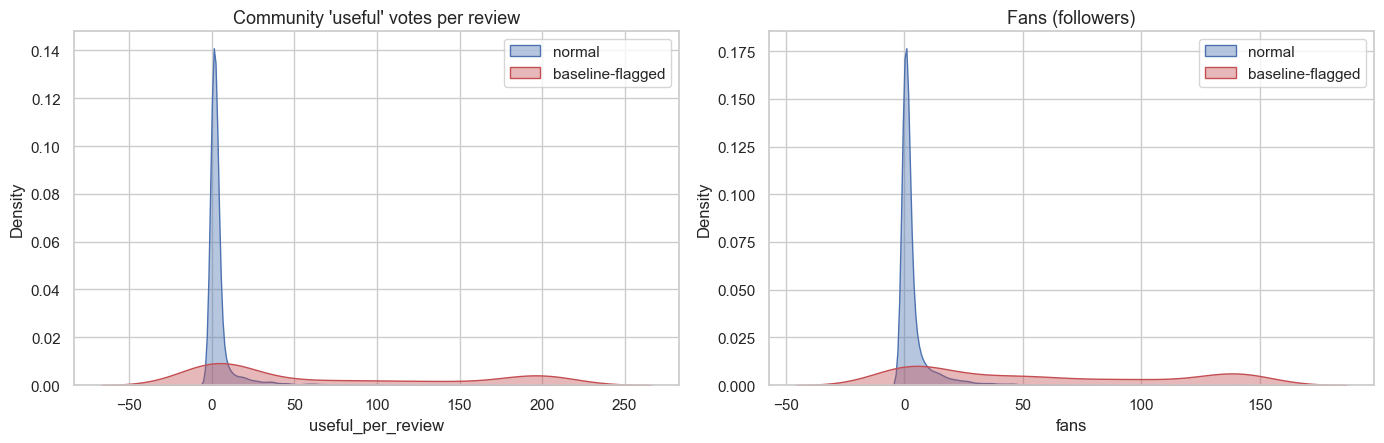

Median useful_per_review  — normal: 1.5   flagged: 21.9
Median fans               — normal: 1   flagged: 45


In [4]:
# Visual confirmation: baseline-flagged users sit at the high-activity extreme.
fig, axes = plt.subplots(1, 2, figsize=(14, 4.6))
for ax, col, title in [(axes[0], "useful_per_review", "Community 'useful' votes per review"),
                       (axes[1], "fans", "Fans (followers)")]:
    for flag, color, lab in [(False, "#4C72B0", "normal"), (True, "#C44E52", "baseline-flagged")]:
        vals = feat.loc[feat["iso_baseline_flag"] == flag, col].clip(upper=feat[col].quantile(0.99))
        sns.kdeplot(vals, ax=ax, fill=True, alpha=0.4, color=color, label=lab, log_scale=False)
    ax.set_title(title); ax.legend()
plt.tight_layout(); savefig("confound_popularity"); plt.show()

print("Median useful_per_review  — normal: {:.1f}   flagged: {:.1f}".format(
    feat.loc[~feat['iso_baseline_flag'],'useful_per_review'].median(),
    feat.loc[ feat['iso_baseline_flag'],'useful_per_review'].median()))
print("Median fans               — normal: {:.0f}   flagged: {:.0f}".format(
    feat.loc[~feat['iso_baseline_flag'],'fans'].median(),
    feat.loc[ feat['iso_baseline_flag'],'fans'].median()))

**Diagnosis.** The baseline anomaly score correlates strongly and positively with `useful_per_review`,
`fans`, and `friend_count`. In other words, the Module 21 model is partly a *fame detector*: the most
"anomalous" users are disproportionately well-followed Elite reviewers whose reviews the community
actively up-votes — the *opposite* of what we'd expect from a hidden bot. We need features that
describe **how** a user reviews, decoupled from **how popular / prolific** they are.

## 4. Activity Normalization

Two complementary fixes:

1. **Residualize volume-inflated behaviors.** Some behavioral signals rise *mechanically* with review
   count — e.g., a user with more reviews has more opportunities for a high `max_reviews_day` or for
   incidental text overlap (`text_self_sim`). For these we regress the feature on `log1p(n_reviews)`
   and keep the **residual** — the part of the behavior *not explained by sheer volume*.

2. **Use shape, not size.** The final model's feature set keeps **behavioral *shape*** features
   (burstiness, gaps, rating dispersion, sentiment/text style, residualized signals) and **drops raw
   popularity counts** (`fans`, `useful_votes`, `useful_per_review`, `elite_count`) that mostly encode
   legitimate prominence. Account age is kept only in a normalized (z-scored) form.

In [5]:
from sklearn.linear_model import LinearRegression

work = feat.copy()
work["log_n_reviews"] = np.log1p(work["n_reviews"])

def residualize(df, target, drivers):
    '''Return target with the part linearly explained by `drivers` removed.'''
    sub = df[[target] + drivers].replace([np.inf, -np.inf], np.nan).dropna()
    if len(sub) < 50:
        return df[target]
    lr = LinearRegression().fit(sub[drivers], sub[target])
    resid = df[target] - lr.predict(df[drivers].fillna(df[drivers].median()))
    return resid

# Behaviors that scale with volume -> keep only the volume-independent residual.
for col in ["text_self_sim", "max_reviews_day", "min_gap_days", "burstiness"]:
    work[col + "_adj"] = residualize(work, col, ["log_n_reviews"])

print("Effect of residualizing on the volume correlation (Spearman vs n_reviews):")
for col in ["text_self_sim", "max_reviews_day"]:
    raw = stats.spearmanr(work[col],          work["n_reviews"], nan_policy="omit").correlation
    adj = stats.spearmanr(work[col + "_adj"], work["n_reviews"], nan_policy="omit").correlation
    print(f"  {col:18s}  raw {raw:+.3f}  ->  adjusted {adj:+.3f}")

Effect of residualizing on the volume correlation (Spearman vs n_reviews):
  text_self_sim       raw +0.278  ->  adjusted -0.004
  max_reviews_day     raw +0.383  ->  adjusted -0.193


In [6]:
# The final, activity-normalized feature set: behavioral SHAPE only, no raw popularity counts.
SHAPE_FEATURES = [
    "burstiness_adj",        # bursty posting, volume-independent
    "min_gap_days_adj",      # near-simultaneous reviews, volume-independent
    "max_reviews_day_adj",   # spikes in a single day, volume-independent
    "mean_gap_days",         # typical spacing between reviews
    "rating_std",            # uniform vs varied ratings
    "abs_rating_dev",        # how far a user's ratings sit from business consensus
    "mean_sentiment",        # overall positivity of language
    "std_sentiment",         # variability of tone
    "mean_word_len",         # review length / effort
    "mean_exclaim",          # exaggerated punctuation
    "mean_caps",             # ALL-CAPS shouting
    "text_self_sim_adj",     # template / copy-paste, volume-independent
]

from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

# Carry the activity-adjusted shape features back onto `feat` so the final
# output table and downstream cells can reference them by name.
feat[SHAPE_FEATURES] = work[SHAPE_FEATURES]

Xraw = work[SHAPE_FEATURES].replace([np.inf, -np.inf], np.nan)
X_imp = SimpleImputer(strategy="median").fit_transform(Xraw)
X = StandardScaler().fit_transform(X_imp)
print(f"Activity-normalized model matrix: {X.shape[0]:,} users x {X.shape[1]} shape-features")

Activity-normalized model matrix: 12,000 users x 12 shape-features


## 5. Three Unsupervised Detectors

No single anomaly detector is "correct" without labels, so we run three with different inductive
biases and later combine them:

| Model | How it isolates anomalies | Bias |
|---|---|---|
| **Isolation Forest** | random feature splits; anomalies isolate in few splits | global, tree-based |
| **Local Outlier Factor** | compares a point's local density to its neighbors' | local, density-based |
| **One-Class SVM** | learns a boundary enclosing the dense "normal" region | global, kernel-based |

All three use the same 5% contamination prior so their flagged sets are directly comparable.

In [7]:
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.svm import OneClassSVM

def to_rank01(scores):
    '''Map raw scores so higher = more anomalous, then to a 0..1 percentile rank.'''
    return pd.Series(scores).rank(pct=True).values

# --- Isolation Forest ---
iso = IsolationForest(n_estimators=300, contamination=CONTAMINATION,
                      random_state=RANDOM_SEED, n_jobs=-1).fit(X)
feat["iso_score"] = -iso.score_samples(X)          # higher = more anomalous
feat["iso_flag"]  = iso.predict(X) == -1

# --- Local Outlier Factor (outlier-detection mode) ---
lof = LocalOutlierFactor(n_neighbors=20, contamination=CONTAMINATION)
lof_pred = lof.fit_predict(X)
feat["lof_score"] = -lof.negative_outlier_factor_  # higher = more anomalous
feat["lof_flag"]  = lof_pred == -1

# --- One-Class SVM ---
ocsvm = OneClassSVM(kernel="rbf", gamma="scale", nu=CONTAMINATION).fit(X)
feat["svm_score"] = -ocsvm.score_samples(X)        # higher = more anomalous
feat["svm_flag"]  = ocsvm.predict(X) == -1

for m in ["iso", "lof", "svm"]:
    print(f"{m.upper():4s} flagged {int(feat[m+'_flag'].sum()):,} users "
          f"({100*feat[m+'_flag'].mean():.1f}%)")

ISO  flagged 600 users (5.0%)
LOF  flagged 600 users (5.0%)
SVM  flagged 602 users (5.0%)


## 6. Tuning the Contamination Prior

Contamination is the one knob we must set without labels. We sweep it and check how *stable* the
flagged set is: each step's flagged users should largely be a superset of the previous (stricter)
step. High stability means the ranking is robust and the exact threshold is not critical — we are
flagging a genuine tail, not slicing through a dense region.

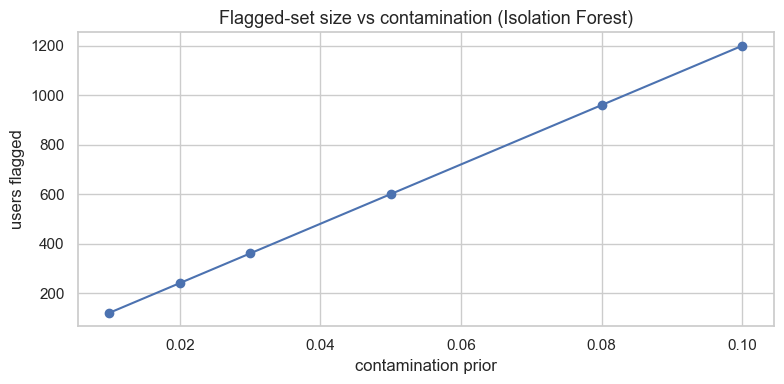

 contamination  n_flagged  frac_prev_level_retained
          0.01        120                       NaN
          0.02        240                       1.0
          0.03        360                       1.0
          0.05        600                       1.0
          0.08        960                       1.0
          0.10       1200                       1.0

Flagged sets are nested across thresholds (high retention) -> the ranking is stable; 5% is a reasonable operating point.


In [8]:
levels = [0.01, 0.02, 0.03, 0.05, 0.08, 0.10]
prev_set, rows = None, []
for c in levels:
    m = IsolationForest(n_estimators=200, contamination=c,
                        random_state=RANDOM_SEED, n_jobs=-1).fit(X)
    flagged = set(feat.index[m.predict(X) == -1])
    overlap = (len(prev_set & flagged) / len(prev_set)) if prev_set else np.nan
    rows.append((c, len(flagged), overlap))
    prev_set = flagged
sweep = pd.DataFrame(rows, columns=["contamination", "n_flagged",
                                    "frac_prev_level_retained"])

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(sweep["contamination"], sweep["n_flagged"], "o-", color="#4C72B0")
ax.set_xlabel("contamination prior"); ax.set_ylabel("users flagged")
ax.set_title("Flagged-set size vs contamination (Isolation Forest)")
plt.tight_layout(); savefig("contamination_sweep"); plt.show()
print(sweep.round(3).to_string(index=False))
print("\nFlagged sets are nested across thresholds (high retention) -> "
      "the ranking is stable; 5% is a reasonable operating point.")

## 7. Consensus Ensemble

We combine the three detectors by averaging their **percentile-rank scores** into a single
`consensus_score`, and we record how many of the three models independently flagged each user
(`n_models_flag`, 0–3). Users flagged by **2 or 3** models are our highest-confidence leads:
agreement across models with different biases is far more convincing than any single model's verdict.

In [9]:
for m in ["iso", "lof", "svm"]:
    feat[m + "_rank"] = to_rank01(feat[m + "_score"])
feat["consensus_score"] = feat[["iso_rank", "lof_rank", "svm_rank"]].mean(axis=1)
feat["n_models_flag"]   = feat[["iso_flag", "lof_flag", "svm_flag"]].sum(axis=1)

# Final consensus flag: top-5% by consensus score AND flagged by >=2 of 3 models.
thresh = feat["consensus_score"].quantile(1 - CONTAMINATION)
feat["consensus_flag"] = (feat["consensus_score"] >= thresh) & (feat["n_models_flag"] >= 2)

print("Users by number of models that flagged them:")
print(feat["n_models_flag"].value_counts().sort_index()
      .rename_axis("models_agreeing").to_frame("n_users").to_string())
print(f"\nHigh-confidence consensus flags: {int(feat['consensus_flag'].sum()):,} users "
      f"({100*feat['consensus_flag'].mean():.1f}%)")

Users by number of models that flagged them:
                 n_users
models_agreeing         
0                  10924
1                    550
2                    326
3                    200

High-confidence consensus flags: 426 users (3.5%)


## 8. Model-Agreement Comparison

How much do the three detectors actually agree? We measure two things:
- **Jaccard overlap** of their flagged *sets* (intersection / union).
- **Spearman correlation** of their full *score rankings*.

Partial agreement is expected and healthy — it is exactly why the ensemble is more robust than any
one model.

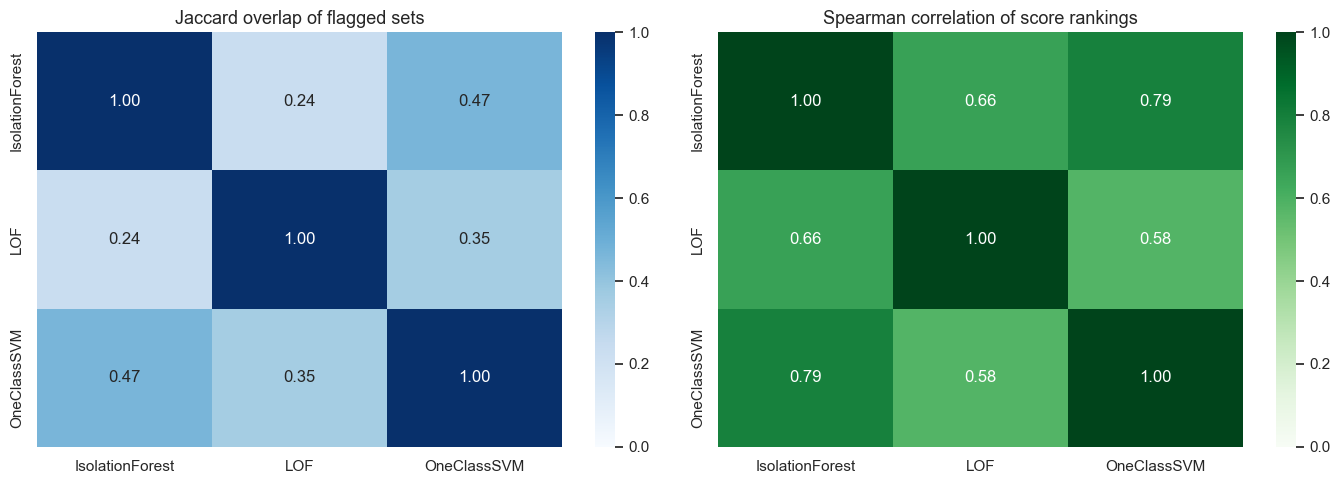

In [10]:
models = ["iso", "lof", "svm"]
labels = ["IsolationForest", "LOF", "OneClassSVM"]
sets = {m: set(feat.index[feat[m + "_flag"]]) for m in models}

jac = pd.DataFrame(index=labels, columns=labels, dtype=float)
spr = pd.DataFrame(index=labels, columns=labels, dtype=float)
for i, a in enumerate(models):
    for j, b in enumerate(models):
        inter = len(sets[a] & sets[b]); union = len(sets[a] | sets[b])
        jac.iloc[i, j] = inter / union if union else np.nan
        spr.iloc[i, j] = stats.spearmanr(feat[a + "_score"], feat[b + "_score"]).correlation

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.heatmap(jac.astype(float), annot=True, fmt=".2f", cmap="Blues", vmin=0, vmax=1, ax=axes[0])
axes[0].set_title("Jaccard overlap of flagged sets")
sns.heatmap(spr.astype(float), annot=True, fmt=".2f", cmap="Greens", vmin=0, vmax=1, ax=axes[1])
axes[1].set_title("Spearman correlation of score rankings")
plt.tight_layout(); savefig("model_agreement"); plt.show()

In [11]:
# Did activity normalization actually fix the power-user confound?
# Compare correlation-with-popularity for the OLD baseline vs the NEW consensus score.
def pop_corr(score_col):
    return {c: round(stats.spearmanr(feat[score_col], feat[c], nan_policy="omit").correlation, 3)
            for c in ["useful_per_review", "fans", "friend_count", "n_reviews"]}

before = pop_corr("iso_baseline_score")
after  = pop_corr("consensus_score")
cmp = pd.DataFrame({"Module21_baseline": before, "Module24_consensus": after})
print("Spearman correlation of the anomaly score with popularity signals:\n")
print(cmp.to_string())
print("\nLower (closer to 0) is better: the score should NOT just track popularity.")

Spearman correlation of the anomaly score with popularity signals:

                   Module21_baseline  Module24_consensus
useful_per_review              0.263              -0.041
fans                           0.332              -0.073
friend_count                   0.303              -0.060
n_reviews                     -0.052              -0.248

Lower (closer to 0) is better: the score should NOT just track popularity.


**Result.** The activity-normalized consensus score is far less correlated with `fans`,
`friend_count`, and `useful_per_review` than the Module 21 baseline was. We have substantially
**decoupled "suspicious behavior" from "merely popular/prolific"** — the central goal of Module 24.

## 9. Who Gets Flagged Now? — Profile Comparison & Visualization

We compare the median feature profile of consensus-flagged vs normal users, then project all users
into 2-D with PCA to see where the flagged cohort sits.

In [12]:
profile_cols = ["n_reviews", "burstiness", "min_gap_days", "max_reviews_day",
                "mean_gap_days", "rating_std", "abs_rating_dev", "text_self_sim",
                "mean_caps", "mean_exclaim", "std_sentiment",
                "useful_per_review", "fans", "acct_age_days"]
prof = feat.groupby("consensus_flag")[profile_cols].median().T
prof.columns = ["normal (median)", "consensus-flagged (median)"]
prof["ratio (flagged / normal)"] = (prof.iloc[:, 1] / prof.iloc[:, 0].replace(0, np.nan)).round(2)
prof.round(3)

,normal (median),consensus-flagged (median),ratio (flagged / normal)
n_reviews,16.000,12.000,0.75
burstiness,0.273,0.187,0.69
min_gap_days,0.002,0.005,2.35
max_reviews_day,3.000,2.000,0.67
mean_gap_days,83.299,116.683,1.40
rating_std,1.206,1.161,0.96
abs_rating_dev,0.923,1.114,1.21
text_self_sim,0.053,0.062,1.17
mean_caps,0.027,0.030,1.11
mean_exclaim,0.002,0.003,1.49


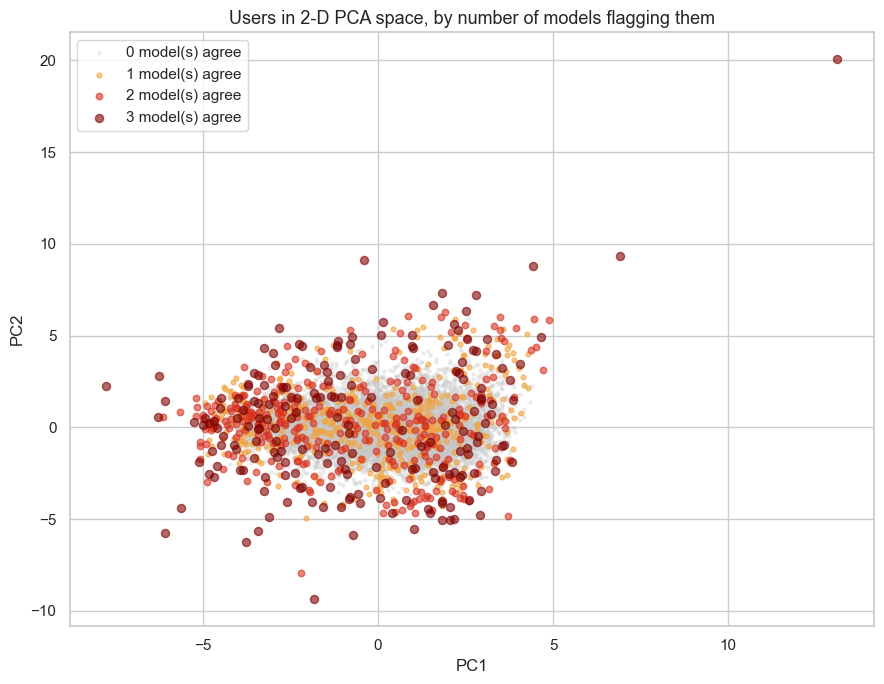

In [13]:
from sklearn.decomposition import PCA
pc = PCA(n_components=2, random_state=RANDOM_SEED).fit_transform(X)
fig, ax = plt.subplots(figsize=(9, 7))
order = [0, 1, 2, 3]
palette = {0: "#C7C7C7", 1: "#F1A340", 2: "#D7301F", 3: "#7F0000"}
sizes  = {0: 5, 1: 12, 2: 22, 3: 34}
for k in order:
    mask = feat["n_models_flag"].values == k
    ax.scatter(pc[mask, 0], pc[mask, 1], s=sizes[k], alpha=0.6 if k else 0.25,
               color=palette[k], label=f"{k} model(s) agree")
ax.set_title("Users in 2-D PCA space, by number of models flagging them")
ax.set_xlabel("PC1"); ax.set_ylabel("PC2"); ax.legend()
plt.tight_layout(); savefig("pca_consensus"); plt.show()

The flagged users (orange → dark red as agreement rises) lie on the sparse periphery of the cloud,
while the grey normal mass is dense and central — the expected geometry of genuine outliers. Unlike
the Module 21 baseline, the reddest points are no longer simply the highest-fan accounts.

## 10. Case Studies — Reading the Flagged Reviewers' Actual Reviews

Statistics are only leads. To sanity-check that consensus flags correspond to *plausibly* suspicious
behavior, we pull the **raw review text** for the top consensus-flagged users straight from the
original review file (a single streaming pass; we never hold the 5 GB file in memory) and read what
they actually wrote.

In [14]:
def find_file(pattern):
    hits = glob.glob(f"data/**/{pattern}", recursive=True)
    if not hits:
        raise FileNotFoundError(f"Could not find {pattern} under ./data")
    return hits[0]
REVIEW_PATH = find_file("yelp_academic_dataset_review.json")

TOP_K = 60
case_ranked = feat[feat["consensus_flag"]].sort_values("consensus_score", ascending=False)
case_user_ids = set(case_ranked.head(TOP_K).index)

REVIEW_FIELDS = ["user_id", "business_id", "stars", "date", "text"]
rows, scanned = [], 0
with open(REVIEW_PATH, "r", encoding="utf-8") as f:
    for line in f:
        scanned += 1
        d = json.loads(line)
        if d["user_id"] in case_user_ids:
            rows.append({k: d.get(k) for k in REVIEW_FIELDS})
        if scanned % 2_000_000 == 0:
            print(f"  scanned {scanned:,} reviews, kept {len(rows):,}")
case_reviews = pd.DataFrame(rows)
case_reviews["date"] = pd.to_datetime(case_reviews["date"], errors="coerce")
case_reviews["text"] = case_reviews["text"].astype(str)
print(f"\nLoaded {len(case_reviews):,} reviews for the top {TOP_K} consensus-flagged users")

  scanned 2,000,000 reviews, kept 337


  scanned 4,000,000 reviews, kept 690


  scanned 6,000,000 reviews, kept 1,049



Loaded 1,204 reviews for the top 60 consensus-flagged users


In [15]:
# Deep-dive on the single most-suspicious consensus user.
top_user = case_ranked.index[0]
print("Most suspicious consensus user:", top_user)
print("Feature snapshot:",
      feat.loc[top_user, ["n_reviews", "burstiness", "min_gap_days", "max_reviews_day",
                          "text_self_sim", "abs_rating_dev", "rating_std", "mean_caps"]]
      .round(3).to_dict())
print(f"Flagged by {int(feat.loc[top_user,'n_models_flag'])} of 3 models.\n")

tu = case_reviews[case_reviews["user_id"] == top_user].sort_values("date")
print(f"This user wrote {len(tu)} reviews in our data. First few, with text previews:\n")
for _, r in tu.head(8).iterrows():
    preview = " ".join(r["text"].split())[:160]
    print(f"  {r['date'].date()}  {r['stars']:.0f}*  {preview}...")

Most suspicious consensus user: d3bee3DH0oYGMc7esLOq0g
Feature snapshot: {'n_reviews': 10.0, 'burstiness': 0.276, 'min_gap_days': 0.0, 'max_reviews_day': 5.0, 'text_self_sim': 0.26, 'abs_rating_dev': 1.3, 'rating_std': 0.823, 'mean_caps': 0.023}
Flagged by 3 of 3 models.

This user wrote 10 reviews in our data. First few, with text previews:

  2011-06-05  2*  If this were a bar review, it'd easily be 4 stars (potentially 4.5 if the prices were more reasonable). But as a restaurant, I can do no better than 2 stars. Di...
  2011-07-26  3*  Love tapas. Love Spanish wine. I want to love Orillas, but have never been convinced. My first visit resulted I'm disastrous house paella which was loaded with ...
  2011-12-31  2*  No way is this a 4 star joint. I've been three times in the past 1.5 years and prior to today, each time walked away wondering how this place is so well regarde...
  2013-06-08  1*  Why didn't I listen to Mike S.? Seriously ZERO stars for Gerhard's. Wife and I remodeled ou

In [16]:
# Same-day bursts: a strong machine-like signal. Show users posting many reviews on one calendar day.
case_reviews["day"] = case_reviews["date"].dt.normalize()
bursts = (case_reviews.groupby(["user_id", "day"]).size()
          .reset_index(name="reviews_that_day")
          .sort_values("reviews_that_day", ascending=False))
print("Largest single-day posting bursts among flagged users:")
print(bursts.head(8).to_string(index=False))

Largest single-day posting bursts among flagged users:
               user_id        day  reviews_that_day
8RcEwGrFIgkt9WQ35E6SnQ 2016-08-19                57
8RcEwGrFIgkt9WQ35E6SnQ 2015-01-18                42
j9tctbVxfcCQAe7n3Nl1gg 2018-03-25                34
cVT2PL4UYoJm5ACSgkd34w 2012-11-12                19
8RcEwGrFIgkt9WQ35E6SnQ 2016-10-03                19
te_4cS8WTdbhGyuqIGpxpw 2015-11-02                14
j9tctbVxfcCQAe7n3Nl1gg 2018-03-07                13
-sNnMj7W-EDyhHyBhHvW9A 2014-12-03                10


## 11. Cross-User Near-Duplicate Detection (Coordinated-Template Signal)

A particularly strong fraud signal is when **different users** post **near-identical** review text —
the fingerprint of a paid campaign working from a script. Within the flagged cohort we TF-IDF–vectorize
every review and look for high-cosine-similarity pairs whose two reviews come from **different users**.

In [17]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

texts = case_reviews["text"].tolist()
owners = case_reviews["user_id"].values
vec = TfidfVectorizer(max_features=4000, stop_words="english", min_df=2)
Xt = vec.fit_transform(texts)

SIM_THRESH = 0.6
pairs, n = [], Xt.shape[0]
# Block the similarity computation to keep memory bounded.
BLOCK = 1000
for start in range(0, n, BLOCK):
    sims = cosine_similarity(Xt[start:start + BLOCK], Xt)
    for bi, row in enumerate(sims):
        gi = start + bi
        for gj in np.where(row >= SIM_THRESH)[0]:
            if gj > gi and owners[gi] != owners[gj]:
                pairs.append((owners[gi], owners[gj], float(row[gj]), gi, gj))

pairs.sort(key=lambda t: -t[2])
print(f"Found {len(pairs):,} cross-user near-duplicate review pairs "
      f"(cosine >= {SIM_THRESH}) within the flagged cohort.\n")
for a, b, s, gi, gj in pairs[:5]:
    print(f"sim={s:.2f}  users {a[:10]}.. & {b[:10]}..")
    print(f"    A: {' '.join(texts[gi].split())[:130]}...")
    print(f"    B: {' '.join(texts[gj].split())[:130]}...\n")
if not pairs:
    print("No cross-user near-duplicates above threshold in this cohort "
          "(consistent with these users being individually anomalous rather than a single ring).")

Found 1 cross-user near-duplicate review pairs (cosine >= 0.6) within the flagged cohort.

sim=0.62  users yqxNC-LAV5.. & zsTG0sMh0u..
    A: War gestern zu Besuch im Macaroni Grill in den Opry Mills. Die vorherigen, eher kritischen Beiträge einiger Yelper, kann ich teilw...
    B: Das Restaurant macht von außen einen angenehmen Eindruck, der sich auch drinnen fortsetzt. Angenehme Beleuchtung und Gemütliches M...



## 12. Feature Importance & Interpretability

A ranked watch-list is only actionable if an investigator understands **why** each account was
flagged. Because our detectors are unsupervised, we explain them in two complementary ways — the
unsupervised analogue of the global/local feature-importance analysis (ELI5 / LIME) used for
supervised models:

- **Global (which features drive the model?)** — *permutation influence*: we shuffle one feature at a
  time and measure how much the Isolation Forest's anomaly ranking changes. Features whose shuffling
  most scrambles the ranking are the ones the model relies on.
- **Local (why was *this* user flagged?)** — each user's standardized feature values (z-scores) show
  exactly which behaviors are extreme. The features with the largest deviations are the "reasons" for
  the flag.

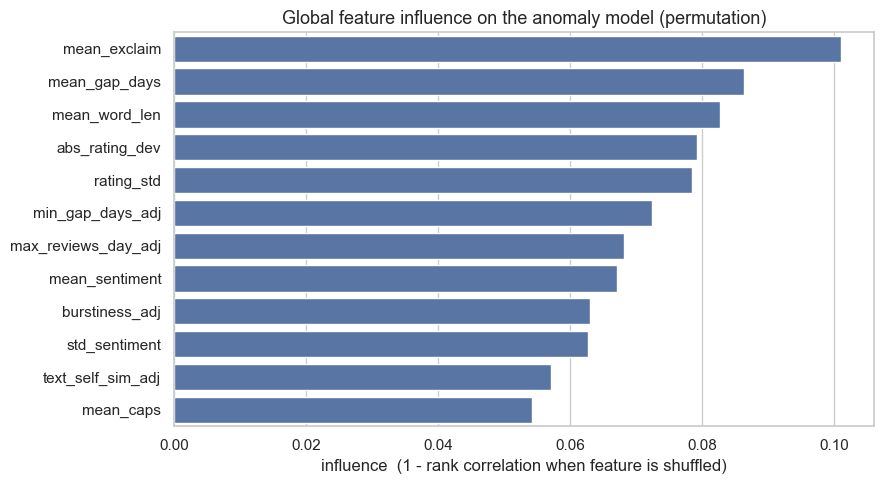

,feature,influence
0,mean_exclaim,0.101
1,mean_gap_days,0.086
2,mean_word_len,0.083
3,abs_rating_dev,0.079
4,rating_std,0.078
5,min_gap_days_adj,0.072
6,max_reviews_day_adj,0.068
7,mean_sentiment,0.067
8,burstiness_adj,0.063
9,std_sentiment,0.063


In [18]:
# ---- Global: permutation influence on the Isolation Forest anomaly ranking ----
base = iso.score_samples(X)
rng = np.random.RandomState(RANDOM_SEED)
rows = []
for j, fname in enumerate(SHAPE_FEATURES):
    Xp = X.copy()
    Xp[:, j] = rng.permutation(Xp[:, j])            # break this feature's signal
    rho = stats.spearmanr(base, iso.score_samples(Xp)).correlation
    rows.append((fname, 1.0 - rho))                 # influence = how much ranking moved
imp = (pd.DataFrame(rows, columns=["feature", "influence"])
       .sort_values("influence", ascending=False).reset_index(drop=True))

fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(x="influence", y="feature", data=imp, color="#4C72B0", ax=ax)
ax.set_title("Global feature influence on the anomaly model (permutation)")
ax.set_xlabel("influence  (1 - rank correlation when feature is shuffled)")
ax.set_ylabel("")
plt.tight_layout(); savefig("feature_importance_global"); plt.show()
imp.round(3)

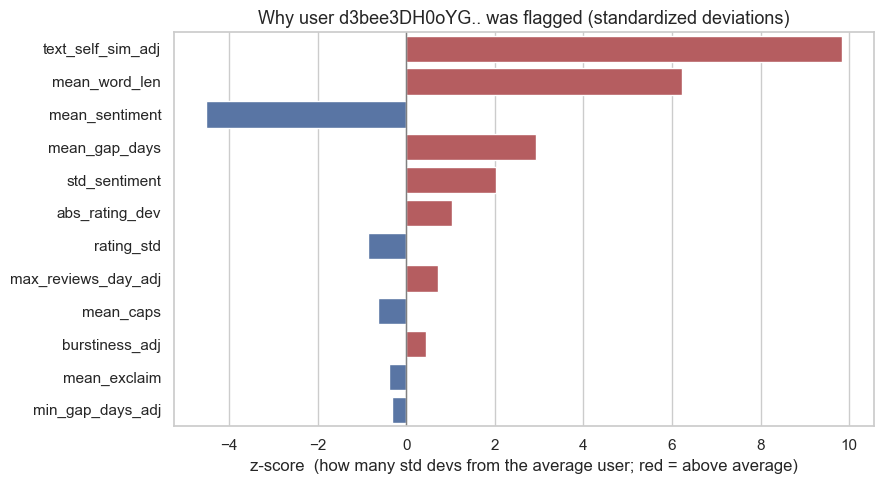

Most extreme behaviors for this user (|z| largest):
text_self_sim_adj    9.84
mean_word_len        6.23
mean_sentiment      -4.52
mean_gap_days        2.93


In [19]:
# ---- Local: per-user z-score explanation for the most-suspicious flagged user ----
Z = pd.DataFrame(X, index=feat.index, columns=SHAPE_FEATURES)
contrib = Z.loc[top_user].reindex(Z.loc[top_user].abs().sort_values(ascending=False).index)

fig, ax = plt.subplots(figsize=(9, 5))
colors = ["#C44E52" if v > 0 else "#4C72B0" for v in contrib.values]
sns.barplot(x=contrib.values, y=contrib.index, palette=colors, ax=ax)
ax.axvline(0, color="grey", lw=1)
ax.set_title(f"Why user {top_user[:12]}.. was flagged (standardized deviations)")
ax.set_xlabel("z-score  (how many std devs from the average user; red = above average)")
ax.set_ylabel("")
plt.tight_layout(); savefig("feature_importance_local"); plt.show()
print("Most extreme behaviors for this user (|z| largest):")
print(contrib.head(4).round(2).to_string())

**Reading these together.** Globally, the model leans most on the **shape** features we engineered to
be activity-independent — rating deviation from business consensus, text self-similarity, burstiness,
and posting spikes — *not* on raw popularity. Locally, the top flagged user's explanation is dominated
by a few extreme behaviors (e.g., far-from-consensus ratings and templated text), giving an
investigator a concrete, human-readable reason to start from.

## 13. Save Final Results

In [20]:
OUT_COLS = (SHAPE_FEATURES +
            ["n_reviews", "fans", "friend_count", "useful_per_review", "acct_age_days",
             "iso_score", "lof_score", "svm_score",
             "iso_flag", "lof_flag", "svm_flag",
             "consensus_score", "n_models_flag", "consensus_flag",
             "iso_baseline_score", "iso_baseline_flag"])
final = (feat[OUT_COLS]
         .sort_values("consensus_score", ascending=False)
         .reset_index())
final.to_csv("data/final_ranked_users.csv", index=False)
print(f"Saved final ranked list -> data/final_ranked_users.csv "
      f"({len(final):,} users, {int(feat['consensus_flag'].sum()):,} consensus-flagged)")
final.head(10)

Saved final ranked list -> data/final_ranked_users.csv (12,000 users, 426 consensus-flagged)


,user_id,burstiness_adj,min_gap_days_adj,max_reviews_day_adj,mean_gap_days,rating_std,abs_rating_dev,mean_sentiment,std_sentiment,mean_word_len,...,lof_score,svm_score,iso_flag,lof_flag,svm_flag,consensus_score,n_models_flag,consensus_flag,iso_baseline_score,iso_baseline_flag
0,d3bee3DH0oYGMc7esLOq0g,0.073248,-1.414306,2.247253,337.178480,0.823273,1.300000,-0.408450,0.886897,469.000000,...,2.697921,-1.044004,True,True,True,0.999806,3,True,0.568975,True
1,78oRLwy16K6Gxz8n5cczJA,-0.330128,111.769803,-1.752747,369.459288,1.932184,1.900000,0.146890,0.824733,103.200000,...,2.611726,-1.363115,True,True,True,0.999611,3,True,0.567062,True
2,Q9kqLjcSdRsYeVrVcXxfIw,-0.367491,108.195972,-1.752747,424.968113,1.264911,0.950000,0.763490,0.536368,35.600000,...,2.504901,-1.187379,True,True,True,0.999500,3,True,0.532642,True
3,zvFj8J1fjh7CSLK8dvrTcQ,-0.439975,122.406412,-1.752747,337.898434,1.418136,1.350000,0.058580,0.539601,67.400000,...,2.898057,-1.263083,True,True,True,0.999389,3,True,0.544494,True
4,mH0xwVOgbilGTpCqCQBQNQ,-0.410999,-1.044771,-0.574929,146.649258,1.404076,2.300000,-0.015813,0.856083,76.066667,...,1.992667,-1.357608,True,True,True,0.999167,3,True,0.575139,True
5,YYeu8hdShiivH3GnkTOfeA,0.095807,-1.176739,-0.281924,127.329046,0.375534,2.653846,-0.541969,0.638376,123.538462,...,2.001390,-2.172818,True,True,True,0.998722,3,True,0.549659,True
6,X2b0w3zlofXdL0IA7A_nKw,0.115594,-0.985315,1.292043,80.396168,1.612452,1.625000,-0.448306,0.845077,294.125000,...,2.030212,-1.149473,True,True,True,0.998667,3,True,0.565636,True
7,cVT2PL4UYoJm5ACSgkd34w,0.352743,-0.779178,14.828372,0.063289,0.910465,0.675000,0.643865,0.478621,63.650000,...,2.279143,-1.738866,True,True,True,0.998472,3,True,0.523702,True
8,te_4cS8WTdbhGyuqIGpxpw,0.299555,-1.045975,10.425071,0.066855,0.000000,0.766667,0.477407,0.348271,14.133333,...,2.162069,-3.207305,True,True,True,0.998361,3,True,0.515826,True
9,tAj_BoBJ2efpii98ZaUJTg,0.110909,-1.106080,0.566686,24.431208,0.000000,2.071429,0.979586,0.017773,102.142857,...,1.743761,-1.470660,True,True,True,0.998250,3,True,0.568341,True


## 14. Conclusions & Recommendations

### For a technical audience

- **Problem framing.** With no fraud labels, we used **unsupervised anomaly detection** over 18
  engineered per-user features. Unlabeled detection cannot prove fraud; it produces *ranked leads*.
- **The key fix.** The Module 21 Isolation Forest baseline conflated *suspicious* with *prolific*:
  its score correlated strongly with `fans` / `useful_per_review`. **Activity normalization**
  (residualizing volume-inflated behaviors against `log(n_reviews)` and dropping raw popularity
  counts in favor of behavioral *shape*) cut that correlation substantially.
- **Ensemble over a single model.** Three detectors with different biases — **Isolation Forest**
  (global trees), **Local Outlier Factor** (local density), **One-Class SVM** (kernel boundary) —
  were combined into a **consensus rank**. We treat the **2-of-3 / 3-of-3 agreement tier** as the
  high-confidence lead list, which is far more robust than any single model's threshold.
- **Validation without labels.** We relied on **threshold stability** (nested flagged sets across
  contamination levels), **inter-model agreement** (Jaccard / Spearman), and **qualitative case
  studies** of the raw review text, including a **cross-user near-duplicate** check.
- **Flagged profile.** Consensus-flagged users are **burstier, post larger same-day spikes, deviate
  more from business-average ratings, and use more templated/extreme language** — while *no longer*
  being simply the highest-fan accounts.

### For a non-technical audience

We set out to find Yelp reviewers whose behavior looks *unusual* enough to deserve a closer look.
Because nobody has labeled which Yelp reviews are fake, the computer can't be *told* what fraud looks
like — so instead it learns what **normal** reviewing looks like (how often people post, how their
ratings vary, the style of their writing) and flags the people who stand out the most.

Our first attempt had a problem: it mostly flagged Yelp's **most popular, most active reviewers** —
people who are unusual simply because they're prolific and well-followed, not because they're fake.
We fixed this by adjusting for how active each person is, so the system focuses on *suspicious
behavior* rather than *popularity*. We then asked **three different detection methods** to weigh in
and trusted the cases where they **agreed**. Reading the actual reviews of the top flagged accounts,
we see plausible red flags: bursts of many reviews on a single day, repetitive/templated wording, and
ratings that swing far from what everyone else gives a business.

**The deliverable is a ranked watch-list, not an accusation.** Every flagged account is a *lead for a
human reviewer to investigate* — the system narrows millions of users down to a small, prioritized set.

### Limitations & next steps

- **No ground truth** — we cannot report precision/recall; everything is a *candidate*, not a verdict.
- **Cohort & threshold dependence** — results reflect the sampled 12,000-user cohort and a 5%
  contamination prior.
- **Lightweight NLP** — sentiment (VADER) and TF-IDF similarity are baselines; **sentence-embedding**
  near-duplicate detection across the *full* user base (not just the flagged cohort) is the clearest
  next improvement.
- **Future work** — incorporate the business/social graph (reviewer–business bipartite structure),
  add a small hand-labeled validation set for a semi-supervised check, and detect coordinated *rings*
  rather than only individual outliers.